# Eyebrow Analysis Pipeline

This notebook uses the MediaPipe Tasks API to extract facial landmarks and determine if a person's eyebrows are more masculine or feminine based on geometric heuristics.

In [1]:
!pip install mediapipe opencv-python matplotlib numpy requests ipywidgets Pillow


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image, ImageOps

mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

## 1. Upload an Image
Click the upload button below to select a front-facing image from your computer.

In [3]:
uploader = widgets.FileUpload(
    accept='image/*',  # Accept all image types
    multiple=False
)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

## 2. Initialize Image & MediaPipe Model
**Note:** Run this cell *after* you have selected an image using the upload button.

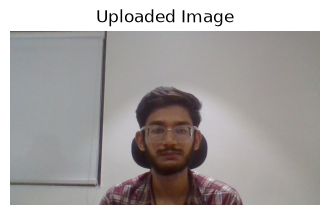

In [9]:
# Ensure an image was uploaded
if uploader.value:
    uploaded_file = uploader.value[0] if isinstance(uploader.value, tuple) else list(uploader.value.values())[0]
    image_stream = io.BytesIO(uploaded_file['content'] if isinstance(uploaded_file, dict) else uploaded_file.content)
    pil_image = Image.open(image_stream)
    # Apply EXIF rotation to fix any sideways images from phones
    pil_image = ImageOps.exif_transpose(pil_image).convert('RGB')
    # Make sure numpy array is contiguous in memory for MediaPipe
    image_rgb = np.ascontiguousarray(np.array(pil_image))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image_rgb)
    plt.title('Uploaded Image')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ Please upload an image in the cell above first!")
    image_rgb = None

In [10]:
if image_rgb is not None:
    # Download the model if it doesn't exist
    model_path = 'face_landmarker.task'
    if not os.path.exists(model_path):
        url = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
        response = requests.get(url)
        with open(model_path, 'wb') as f:
            f.write(response.content)

    # Initialize Face Landmarker
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(base_options=base_options,
                                           output_face_blendshapes=False,
                                           output_facial_transformation_matrixes=False,
                                           num_faces=1)
    detector = vision.FaceLandmarker.create_from_options(options)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = detector.detect(mp_image)

    if detection_result.face_landmarks:
        face_landmarks = detection_result.face_landmarks[0]
        print("✅ Face landmarks detected!")
    else:
        print("❌ No face detected in the image.")
        face_landmarks = None
else:
    face_landmarks = None

✅ Face landmarks detected!


## 3. Eyebrow Geometric Heuristics

In [11]:
def analyze_eyebrows(landmarks, image_width, image_height):
    # Right Eye (person's right, left side of image)
    right_eye_center = np.array([landmarks[473].x * image_width, landmarks[473].y * image_height])
    right_eb_center = np.array([landmarks[65].x * image_width, landmarks[65].y * image_height])
    right_eb_inner = np.array([landmarks[55].x * image_width, landmarks[55].y * image_height])
    right_eb_outer = np.array([landmarks[105].x * image_width, landmarks[105].y * image_height])
    
    # Left Eye (person's left, right side of image)
    left_eye_center = np.array([landmarks[468].x * image_width, landmarks[468].y * image_height])
    left_eb_center = np.array([landmarks[295].x * image_width, landmarks[295].y * image_height])
    left_eb_inner = np.array([landmarks[285].x * image_width, landmarks[285].y * image_height])
    left_eb_outer = np.array([landmarks[334].x * image_width, landmarks[334].y * image_height])
    
    # 1. Eye-to-Eyebrow Distance (Vertical distance)
    left_distance = left_eye_center[1] - left_eb_center[1]
    right_distance = right_eye_center[1] - right_eb_center[1]
    avg_distance = (left_distance + right_distance) / 2.0
    
    # Normalize distance based on face height to make it scale invariant
    chin = np.array([landmarks[152].x * image_width, landmarks[152].y * image_height])
    top_head = np.array([landmarks[10].x * image_width, landmarks[10].y * image_height])
    face_height = chin[1] - top_head[1]
    
    norm_distance = avg_distance / face_height
    
    # 2. Arch Height (Difference between center y and average of inner/outer y)
    left_arch = ((left_eb_inner[1] + left_eb_outer[1]) / 2.0) - left_eb_center[1]
    right_arch = ((right_eb_inner[1] + right_eb_outer[1]) / 2.0) - right_eb_center[1]
    avg_arch = (left_arch + right_arch) / 2.0
    
    norm_arch = avg_arch / face_height
    
    return norm_distance, norm_arch, face_height

if face_landmarks:
    h, w, _ = image_rgb.shape
    norm_distance, norm_arch, _ = analyze_eyebrows(face_landmarks, w, h)
    print(f"Normalized Eye-to-Eyebrow Distance: {norm_distance:.4f} (Smaller = Masculine)")
    print(f"Normalized Eyebrow Arch Height: {norm_arch:.4f} (Larger = Feminine)")

Normalized Eye-to-Eyebrow Distance: 0.1383 (Smaller = Masculine)
Normalized Eyebrow Arch Height: 0.0001 (Larger = Feminine)


## 4. Scoring logic

In [12]:
def calculate_gender_score(norm_distance, norm_arch):
    # distance: small (~0.05) is masculine (+1), large (~0.09) is feminine (-1)
    dist_score = 1.0 - 2.0 * np.clip((norm_distance - 0.05) / (0.09 - 0.05), 0, 1)
    
    # arch: small (~0.005) is masculine (+1), large (~0.035) is feminine (-1)
    arch_score = 1.0 - 2.0 * np.clip((norm_arch - 0.005) / (0.035 - 0.005), 0, 1)
    
    # Average them
    final_score = (dist_score + arch_score) / 2.0
    
    # Apply a 1.5x multiplier to make it more sensitive/opinionated, reducing the "Neutral" cases.
    final_score = np.clip(final_score * 1.5, -1.0, 1.0)
    return final_score

if face_landmarks:
    # score is -1 (Hyper Feminine) to +1 (Hyper Masculine)
    score_m_to_f = calculate_gender_score(norm_distance, norm_arch)
    
    if score_m_to_f > 0.15:
        label = "Masculine"
    elif score_m_to_f < -0.15:
        label = "Feminine"
    else:
        label = "Neutral"

## 5. UI Visualization (Matched to Reference)

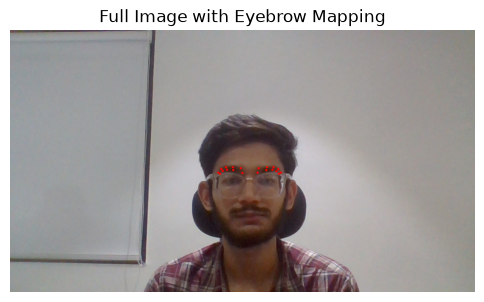

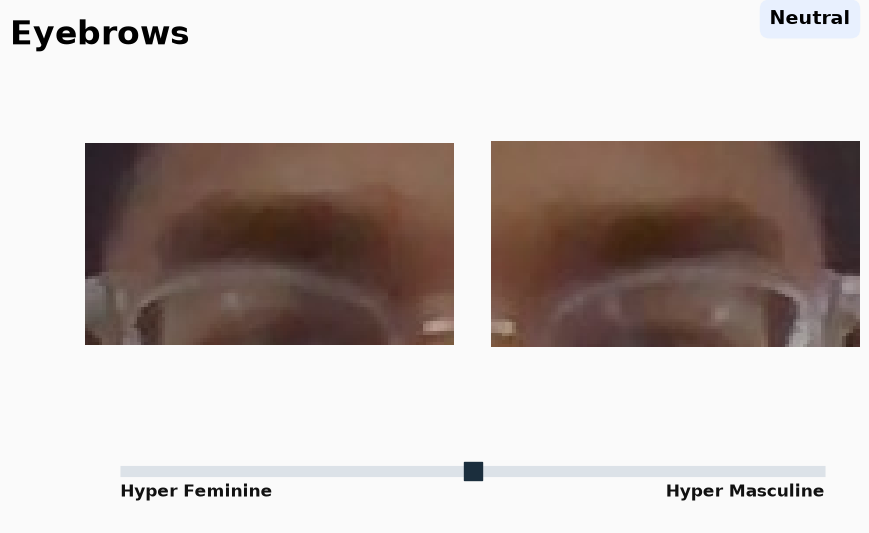

In [13]:
def crop_eyebrow(image, landmarks, idxs, w, h, padding_x=20, padding_y=20):
    points = np.array([(int(landmarks[i].x * w), int(landmarks[i].y * h)) for i in idxs])
    x_min, y_min = np.min(points, axis=0)
    x_max, y_max = np.max(points, axis=0)
    
    x_min = max(0, x_min - padding_x)
    y_min = max(0, y_min - padding_y)
    x_max = min(w, x_max + padding_x)
    y_max = min(h, y_max + padding_y)
    
    return image[y_min:y_max, x_min:x_max]

if face_landmarks:
    h, w, _ = image_rgb.shape
    
    right_eyebrow_idxs = [46, 52, 53, 55, 63, 65, 66, 70, 105, 107]
    left_eyebrow_idxs = [276, 282, 283, 285, 293, 295, 296, 300, 334, 336]
    
    # 1. Show the full image with the red dots mapping overlay
    annotated_image = image_rgb.copy()
    for idx in right_eyebrow_idxs + left_eyebrow_idxs:
        x, y = int(face_landmarks[idx].x * w), int(face_landmarks[idx].y * h)
        cv2.circle(annotated_image, (x, y), 3, (255, 0, 0), -1)
        
    plt.figure(figsize=(6, 6))
    plt.imshow(annotated_image)
    plt.title("Full Image with Eyebrow Mapping")
    plt.axis('off')
    plt.show()

    # 2. Show the clean cropped UI visualization
    # Crop the eyebrows from the CLEAN image (no red dots)
    right_eyebrow_crop = crop_eyebrow(image_rgb, face_landmarks, right_eyebrow_idxs, w, h)
    left_eyebrow_crop = crop_eyebrow(image_rgb, face_landmarks, left_eyebrow_idxs, w, h)
    
    # Setup Matplotlib Figure to simulate the UI layout
    fig = plt.figure(figsize=(10, 6))
    fig.patch.set_facecolor('#FAFAFA')
    
    # Title and Badge
    plt.suptitle("Eyebrows", fontsize=24, fontweight='bold', ha='left', x=0.05, y=0.95)
    fig.text(0.85, 0.95, label, fontsize=14, fontweight='bold', ha='center', va='center', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#E8F0FE', edgecolor='none', alpha=1.0))

    # --- Eyebrow Images Panel ---
    ax1 = plt.subplot2grid((4, 2), (0, 0), rowspan=3)
    ax1.imshow(right_eyebrow_crop)
    ax1.axis('off')

    ax2 = plt.subplot2grid((4, 2), (0, 1), rowspan=3)
    ax2.imshow(left_eyebrow_crop)
    ax2.axis('off')

    # --- Slider / Progress Bar Panel ---
    ax3 = plt.subplot2grid((4, 2), (3, 0), colspan=2)
    ax3.set_facecolor('#FAFAFA')
    
    # Draw the track
    ax3.hlines(0, -1, 1, color='#DCE2E8', linewidth=8, zorder=1)
    
    # Draw the dynamic marker
    ax3.scatter(score_m_to_f, 0, color='#1B2E3D', s=150, marker='s', zorder=2)
    
    ax3.set_xlim(-1.1, 1.1)
    ax3.set_ylim(-1, 1)
    ax3.axis('off')
    
    # Labels
    ax3.text(-1, -0.4, 'Hyper Feminine', ha='left', va='center', fontsize=12, fontweight='bold', color='#111')
    ax3.text(1, -0.4, 'Hyper Masculine', ha='right', va='center', fontsize=12, fontweight='bold', color='#111')

    plt.subplots_adjust(top=0.85, hspace=0.1, wspace=0.1)
    plt.show()